## MAS Testing Notebook — Shared Blackboard Multi-Agent Insider Threat Detection

**Inference-only pipeline (no training). All models loaded from saved files.**

- Agent 1 (CAE): `agent1_cae_new.pth` + `scaler.pkl` + `cae_threshold.npy`
- Agent 2 (DistilBERT): MPNet snippet extraction + fine-tuned DistilBERT (same strategy as `testing_175.ipynb`)
- Agent 3 (Temporal): `agent3_baselines_new.pkl`
- Agent 4 (IF Orchestrator): `agent4_orchestrator_new.pkl` + `if_threshold.npy`
- Data: `Test_sessions.csv`

In [1]:
import os
import gc
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from sentence_transformers import SentenceTransformer, util
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm.auto import tqdm
from scipy.stats import rankdata
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported")


Libraries Imported


### Configuration

In [2]:
# =========================================================
# PATHS — update these to match your file locations
# =========================================================
CONFIG = {
    # --- Test Data ---
    "test_csv": r"C:\Users\talal\Desktop\FYP\DSIT\DatasetsProcessed\Test_sessions.csv",

    # --- Saved Model Files ---
    "agent1_path":    "agent1_cae_new.pth",
    "scaler_path":    "scaler.pkl",
    "cae_threshold_path": "cae_threshold.npy",
    "agent3_path":    "agent3_baselines_new.pkl",
    "agent4_path":    "agent4_orchestrator_new.pkl",
    "if_threshold_path":  "if_threshold.npy",

    # --- Agent 2 (DistilBERT) ---
    "agent2_model_dir": r"D:\LLM Fine Tuning New Dataset\Normal and Malicious\Augmentation 250\final_insider_threat_model",
    "agent2_scanner":   "all-mpnet-base-v2",
}

# --- Blackboard hyper-parameters (must match training) ---
NLP_BOOST_MULTIPLIER = 1.5   # boost factor when CAE flags a session
NLP_FLAG_PERCENTILE  = 90    # percentile above which NLP score is "high"

# --- Test set composition ---
# ALL malicious sessions are always kept.
# Benign sessions are capped at this number (None = keep all).
DOWNSAMPLE_TEST_BENIGN = 10_000

# --- Numerical feature columns (must match training order exactly) ---
NUM_COLS = [
    'duration', 'is_weekend', 'is_after_hour', 'emails_count',
    'ext_emails_count', 'attachments_count', 'total_email_size',
    'http_count', 'cloud_uploads_count', 'usb_connects_count',
    'file_copies_count', 'file_to_usb_count'
]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print("Configuration loaded.")

Device: cpu
Configuration loaded.


### Shared Blackboard

In [3]:
class Blackboard:
    """
    Shared communication hub for the multi-agent system.
    Agents write their scores, thresholds, and flags here.
    Downstream agents read upstream results to adapt their behaviour.
    """
    def __init__(self, n_samples):
        self.n_samples = n_samples
        self.data = {}
        self.messages = []

    def write(self, agent_name, key, value, msg=None):
        self.data[f"{agent_name}:{key}"] = value
        if msg:
            self.messages.append({'agent': agent_name, 'key': key, 'msg': msg})
            print(f"  [Blackboard] {msg}")

    def read(self, agent_name, key):
        return self.data.get(f"{agent_name}:{key}", None)

    def get_flag(self, agent_name, key):
        arr = self.read(agent_name, key)
        if arr is None:
            return np.zeros(self.n_samples, dtype=bool)
        return arr.astype(bool)

    def get_messages(self):
        return list(self.messages)

    def summary(self):
        print(f"\n{'='*60}")
        print(f"  Blackboard Summary ({len(self.data)} entries, {len(self.messages)} messages)")
        print(f"{'='*60}")
        for key, val in self.data.items():
            if isinstance(val, np.ndarray):
                print(f"  {key}: ndarray shape={val.shape}, dtype={val.dtype}")
            else:
                print(f"  {key}: {type(val).__name__} = {val}")
        for m in self.messages:
            print(f"  [{m['agent']}] {m['msg']}")
        print(f"{'='*60}\n")

print("Blackboard class defined.")

Blackboard class defined.


### Model Class Definitions

In [4]:
# =========================================================
# Agent 1 — Contractive Autoencoder
# =========================================================
class ContractiveAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(ContractiveAutoencoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 32)
        self.fc4 = nn.Linear(32, input_dim)
        self.relu    = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        h1   = self.relu(self.fc1(x))
        h2   = self.sigmoid(self.fc2(h1))   # latent code
        h3   = self.relu(self.fc3(h2))
        recon = self.sigmoid(self.fc4(h3))
        return recon, h2


# =========================================================
# Agent 2 — MPNet Scanner + Augmented DistilBERT (Binary)
# =========================================================
class DistilBertThreatAgent:
    """
    Two-stage pipeline (Augmentation-250 strategy):
      Stage 1 (MPNet): Chunk text (size=1200, overlap=200) → cosine similarity
                       against a single combined malicious anchor → pick the
                       most suspicious chunk per session.
      Stage 2 (DistilBERT): Binary classifier (Normal=0, Malicious=1).
      Score = P(Malicious) = probs[:, 1]  (higher = more threatening).
    """

    # Single combined anchor covering both job-search and exfiltration signals
    MALICIOUS_ANCHOR_TEXT = (
        "I want to quit my job. I am applying for a new position. "
        "looking for a new job, applying for positions, sending resume, interview, recruiter, linkedin, "
        "glassdoor, monster.com, taleo, careerbuilder, layoff rumors, downsizing anxiety, severance package, "
        "Boeing, Lockheed Martin, Raytheon, Northrop Grumman, mushrooms, suillus spraguei, bad date email signature, "
        "updating cv, reference check, salary negotiation, I am stealing company secrets. "
        "I am uploading confidential files to a personal account. "
        "stealing proprietary data, uploading confidential files to cloud storage, dropbox, google drive, "
        "wikileaks, julian assange, the real story about dtaa, jainism, anekantavada, gandhi, "
        "m249 saw, fuzes, hazard analysis, strategic systems program, hms lion, uranus operation, cockatoo, "
        "copying files to usb, removable media, thumb drive, tor browser, encryption, steganography"
    )

    LABEL_MAP = {0: "Normal", 1: "Malicious"}

    def __init__(self, scanner_model_name, classifier_dir, device):
        self.device = device
        print(f"Agent 2: Loading MPNet scanner ({scanner_model_name})...")
        self.scanner = SentenceTransformer(scanner_model_name, device=str(device))
        # Single combined anchor vector
        self.anchor_vec = self.scanner.encode(self.MALICIOUS_ANCHOR_TEXT, convert_to_tensor=True)
        print(f"Agent 2: Loading fine-tuned DistilBERT (Augmentation-250) from {classifier_dir}...")
        self.tokenizer  = AutoTokenizer.from_pretrained(classifier_dir)
        self.classifier = AutoModelForSequenceClassification.from_pretrained(classifier_dir)
        self.classifier.to(device)
        self.classifier.eval()
        print("Agent 2: Models loaded.")

    def _prepare_full_text(self, df):
        return (
            "EMAIL: "           + df['email_content_text'].fillna('').astype(str) +
            " | HTTP URL: "     + df['http_url_text'].fillna('').astype(str) +
            " | HTTP CONTENT: " + df['http_content_text'].fillna('').astype(str) +
            " | FILE NAMES: "   + df['file_names_text'].fillna('').astype(str) +
            " | FILE CONTENT: " + df['file_content_text'].fillna('').astype(str)
        ).tolist()

    def _get_best_snippet(self, text):
        """
        Stage 1: Chunk text (size=1200, overlap=200), encode with MPNet,
        return the chunk most similar to the combined malicious anchor.
        """
        if pd.isna(text) or text.strip() == "":
            return ""
        chunk_size, overlap = 1200, 200
        chunks = [text[i:i + chunk_size] for i in range(0, len(text), chunk_size - overlap)]
        if not chunks:
            chunks = [text[:512]]
        chunks = chunks[:100]   # cap at 100 chunks per session

        embs   = self.scanner.encode(chunks, convert_to_tensor=True, show_progress_bar=False)
        scores = util.cos_sim(embs, self.anchor_vec).squeeze()
        if scores.ndim == 0:
            scores = scores.unsqueeze(0)
        return chunks[torch.argmax(scores).item()]

    def _classify_batch(self, snippets):
        """
        Stage 2: Binary DistilBERT inference.
        Returns softmax probabilities of shape (batch_size, 2).
        """
        inputs = self.tokenizer(snippets, return_tensors="pt", padding=True,
                                truncation=True, max_length=512).to(self.device)
        with torch.no_grad():
            logits = self.classifier(**inputs).logits
        return torch.nn.functional.softmax(logits, dim=-1).cpu().numpy()

    def predict_score(self, df, batch_size=128):
        """
        Full two-stage prediction.
        Returns:
            threat_probs  — P(Malicious) per session  (used as anomaly score)
            pred_labels   — argmax class label (0=Normal, 1=Malicious)
        """
        print("Agent 2: Preparing text data...")
        texts            = self._prepare_full_text(df)
        all_threat_probs = np.zeros(len(texts))
        all_pred_labels  = np.zeros(len(texts), dtype=int)

        print(f"Agent 2: Running MPNet + DistilBERT on {len(texts):,} sessions...")
        for i in tqdm(range(0, len(texts), batch_size), desc="Agent 2 (DistilBERT)"):
            batch_texts    = texts[i:i + batch_size]
            snippets       = [self._get_best_snippet(t) for t in batch_texts]
            non_empty_mask = [bool(s.strip()) for s in snippets]

            if any(non_empty_mask):
                ne_snippets = [s for s, m in zip(snippets, non_empty_mask) if m]
                ne_indices  = [j for j, m in enumerate(non_empty_mask) if m]
                probs        = self._classify_batch(ne_snippets)   # (n, 2)
                # Score = P(Malicious) = probs[:, 1]
                threat_probs = probs[:, 1]
                pred_labels  = np.argmax(probs, axis=1)
                for idx, orig in enumerate(ne_indices):
                    all_threat_probs[i + orig] = threat_probs[idx]
                    all_pred_labels[i + orig]  = pred_labels[idx]

        for cid, cname in self.LABEL_MAP.items():
            print(f"  Agent 2 — {cname}: {(all_pred_labels == cid).sum():,} sessions")
        return all_threat_probs, all_pred_labels

    def predict_score_with_blackboard(self, df, blackboard, boost_multiplier=1.5, batch_size=128):
        """
        Blackboard-aware scoring:
        - Computes base P(Malicious) scores.
        - Reads Agent 1's high_flag from the blackboard.
        - Boosts score by `boost_multiplier` for sessions CAE-flagged as high anomaly.
        """
        base_scores, pred_labels = self.predict_score(df, batch_size=batch_size)
        cae_flag = blackboard.get_flag('agent1', 'high_flag')

        if cae_flag is not None and cae_flag.any():
            n_boosted    = cae_flag.sum()
            boosted = np.where(cae_flag,
                               np.clip(base_scores * boost_multiplier, 0.0, 1.0),
                               base_scores)
            blackboard.write('agent2', 'scores', boosted,
                             msg=f"Agent2 boosted {n_boosted} sessions by "
                                 f"{boost_multiplier}x (Agent1 CAE flag)")
        else:
            boosted = base_scores
            blackboard.write('agent2', 'scores', base_scores,
                             msg="Agent2 ran without boost (no Agent1 flags)")

        blackboard.write('agent2', 'base_scores', base_scores)
        blackboard.write('agent2', 'pred_labels', pred_labels)
        return boosted


# =========================================================
# Agent 3 — Temporal Baseline Agent
# =========================================================
class TemporalBaselineAgent:
    def __init__(self, feature_cols):
        self.feature_cols = feature_cols
        self.user_means = self.user_stds = self.global_mean = self.global_std = None

    def predict_score(self, test_df):
        """Per-user Z-score deviation."""
        means_dict = self.user_means.to_dict('index')
        stds_dict  = self.user_stds.to_dict('index')
        x     = test_df[self.feature_cols].values.astype(np.float64)
        means = np.zeros(x.shape, dtype=np.float64)
        stds  = np.ones(x.shape,  dtype=np.float64)
        for i, user in enumerate(test_df['user']):
            if user in means_dict:
                means[i] = list(means_dict[user].values())
                stds[i]  = list(stds_dict[user].values())
            else:
                means[i] = self.global_mean.values
                stds[i]  = self.global_std.values
        stds = np.maximum(stds, 1e-6)
        z = np.clip((x - means) / stds, -10.0, 10.0)
        return np.sqrt(np.mean(z**2, axis=1))

    def _compute_global_z_scores(self, test_df):
        x = test_df[self.feature_cols].values.astype(np.float64)
        gm = np.tile(self.global_mean.values, (len(x), 1))
        gs = np.maximum(np.tile(self.global_std.values, (len(x), 1)), 1e-6)
        z  = np.clip((x - gm) / gs, -10.0, 10.0)
        return np.sqrt(np.mean(z**2, axis=1))

    def predict_score_with_blackboard(self, test_df, blackboard):
        print("Agent 3: Computing per-user Z-Score Deviations...")
        base_scores      = self.predict_score(test_df)
        cae_high         = blackboard.get_flag('agent1', 'high_flag')
        nlp_high         = blackboard.get_flag('agent2', 'high_flag')
        upstream_flagged = cae_high | nlp_high
        n_flagged        = upstream_flagged.sum()
        if n_flagged > 0:
            print(f"Agent 3: {n_flagged} sessions flagged upstream — computing global baselines...")
            global_scores   = self._compute_global_z_scores(test_df)
            enhanced_scores = np.where(upstream_flagged,
                                       np.maximum(base_scores, global_scores),
                                       base_scores)
            blackboard.write('agent3', 'scores', enhanced_scores,
                             msg=f"Agent3 enhanced {n_flagged} sessions with global baselines")
            blackboard.write('agent3', 'base_scores', base_scores)
            return enhanced_scores
        else:
            print("Agent 3: No upstream flags — using standard per-user scoring.")
            blackboard.write('agent3', 'scores', base_scores,
                             msg="Agent3 ran without enhancement (no upstream flags)")
            blackboard.write('agent3', 'base_scores', base_scores)
            return base_scores

    def load(self, path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        self.user_means  = data['user_means']
        self.user_stds   = data['user_stds']
        self.global_mean = data['global_mean']
        self.global_std  = data['global_std']
        print(f"Agent 3: Loaded baselines for {len(self.user_means)} users.")

print("All model classes defined.")

All model classes defined.


### Evaluation Helper

In [5]:
def evaluate_single_agent(agent_name, scores, y_true):
    """Compute ROC-AUC, AP and print a report at the best threshold."""
    if len(np.unique(y_true)) < 2:
        print(f"  [{agent_name}] Cannot compute AUC — only one class present.")
        return float('nan'), scores

    auc = roc_auc_score(y_true, scores)
    ap  = average_precision_score(y_true, scores)
    print(f"\n{'='*60}")
    print(f"  {agent_name} — Individual Evaluation")
    print(f"{'='*60}")
    print(f"  ROC-AUC: {auc:.4f}")
    print(f"  Average Precision (AP): {ap:.6f}")

    precisions, recalls, thresholds_pr = precision_recall_curve(y_true, scores)
    target_recall = 0.90
    valid_mask = recalls[:-1] >= target_recall
    if valid_mask.any():
        best_idx   = np.argmax(precisions[:-1][valid_mask])
        chosen_idx = np.where(valid_mask)[0][best_idx]
    else:
        f1 = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
        chosen_idx = np.argmax(f1)
    best_threshold = thresholds_pr[chosen_idx]
    print(f"  Optimal threshold (recall≥{target_recall:.0%}): {best_threshold:.6f}")
    print(f"  → Precision: {precisions[chosen_idx]:.4f}, Recall: {recalls[chosen_idx]:.4f}")

    preds = (scores >= best_threshold).astype(int)
    print(f"\n  Classification Report at optimal threshold:")
    print(classification_report(y_true, preds, target_names=['Benign', 'Malicious'], zero_division=0))
    n_mal     = y_true.sum()
    n_detected = ((preds == 1) & (y_true == 1)).sum()
    n_fp       = ((preds == 1) & (y_true == 0)).sum()
    print(f"  Malicious detected: {n_detected}/{n_mal}  |  False positives: {n_fp}")
    return auc, scores

print("Evaluation helper defined.")

Evaluation helper defined.


### Step 1 — Load Test Data (`Test_sessions.csv`)

In [6]:
print("Loading Test_sessions.csv...")
df_raw = pd.read_csv(CONFIG['test_csv'])

# Restore datetime columns if present
for col in ['start', 'end']:
    if col in df_raw.columns:
        df_raw[col] = pd.to_datetime(df_raw[col], errors='coerce')

# Ensure text columns exist and are strings
text_cols = ['email_content_text', 'http_url_text', 'http_content_text',
             'file_names_text', 'file_content_text']
for col in text_cols:
    if col not in df_raw.columns:
        df_raw[col] = ""
    else:
        df_raw[col] = df_raw[col].fillna("").astype(str)

# ── Build the test set ──────────────────────────────────────
df_malicious = df_raw[df_raw['label'] > 0].copy()
df_benign    = df_raw[df_raw['label'] == 0].copy()

if DOWNSAMPLE_TEST_BENIGN is not None and len(df_benign) > DOWNSAMPLE_TEST_BENIGN:
    df_benign = df_benign.sample(n=DOWNSAMPLE_TEST_BENIGN, random_state=42)
    print(f"  Benign downsampled to {DOWNSAMPLE_TEST_BENIGN:,}")

test_df = pd.concat([df_malicious, df_benign]).sample(frac=1, random_state=42).reset_index(drop=True)
y_test  = (test_df['label'] > 0).astype(int).values

print(f"\n  Test set: {(y_test == 0).sum():,} Benign  |  {y_test.sum()} Malicious")
print(f"  Total:    {len(test_df):,} sessions")
if y_test.sum() > 0:
    print(f"  Imbalance ratio: 1:{(y_test == 0).sum() // y_test.sum()}")
test_df.head()

Loading Test_sessions.csv...

  Test set: 10,000 Benign  |  47 Malicious
  Total:    10,047 sessions
  Imbalance ratio: 1:212


,Unnamed: 0,user,start,end,duration,is_weekend,is_after_hour,emails_count,ext_emails_count,attachments_count,...,http_count,http_url_text,http_content_text,cloud_uploads_count,usb_connects_count,file_copies_count,file_to_usb_count,file_names_text,file_content_text,label
0,693,ZER0085,2011-02-28 07:34:00,2011-02-28 15:34:00,28800.0,0,0,9,0,0,...,75,http://match.com/Slayer/elyse/Vna_Qbhtnyq_ZpYn...,"He was commissioned as a pilot in 1932, and un...",0,0,0,0,,,0
1,1225,SXW0537,2011-05-23 08:37:00,2011-05-23 16:37:00,28800.0,0,0,8,2,0,...,91,http://fbcdn.net/Harold_Pinter/krapps/Ivrg_Anz...,Most of the survivors fled to China or French-...,0,0,0,0,,,0
2,7165,SKL0739,2010-09-29 07:01:00,2010-09-29 15:01:00,28800.0,0,0,6,4,0,...,89,http://kayak.com/Talbot_Baines_Reed/quigly/Oel...,Bryce sits at a much higher elevation than nea...,5,0,0,0,,,0
3,9861,SDN2932,2010-05-24 10:27:54,2010-05-24 16:58:00,23406.0,0,0,3,0,3,...,19,http://conduit.com/Drapiers_Letters/midleton/I...,"Hoc and his lieutenants, Chinh and Nguyen Than...",0,0,0,0,,,0
4,7207,SJW3131,2011-04-18 12:09:53,2011-04-18 16:00:00,13807.0,0,0,7,2,4,...,41,http://yahoo.com/Wiglaf_of_Mercia/beorhtwulf/P...,The South American Classification Committee ha...,1,0,0,0,,,0


### Step 2 — Agent 1 (CAE): Load & Score

In [7]:
print("\n" + "="*60)
print("  AGENT 1 — Contractive Autoencoder (CAE)")
print("="*60)

# ── Load scaler ─────────────────────────────────────────────
print("Loading scaler...")
with open(CONFIG['scaler_path'], 'rb') as f:
    scaler = pickle.load(f)

# ── Load saved CAE threshold ────────────────────────────────
cae_threshold = float(np.load(CONFIG['cae_threshold_path']))
print(f"Loaded CAE threshold: {cae_threshold:.6f}")

# ── Scale numerical features ────────────────────────────────
X_test_num = torch.FloatTensor(scaler.transform(test_df[NUM_COLS])).to(device)

# ── Load CAE model weights ──────────────────────────────────
print(f"Loading CAE from {CONFIG['agent1_path']}...")
agent1_model = ContractiveAutoencoder(input_dim=len(NUM_COLS)).to(device)
agent1_model.load_state_dict(torch.load(CONFIG['agent1_path'], map_location=device))
agent1_model.eval()
print("Agent 1 CAE loaded.")

# ── Compute reconstruction errors ───────────────────────────
loss_fn = nn.MSELoss(reduction='none')
with torch.no_grad():
    recon_test, _ = agent1_model(X_test_num)
    reconstruction_errors = torch.mean(
        loss_fn(recon_test, X_test_num), dim=1
    ).cpu().numpy()

print(f"\n  Reconstruction error — min: {reconstruction_errors.min():.6f}, "      f"max: {reconstruction_errors.max():.6f}, mean: {reconstruction_errors.mean():.6f}")
if y_test.sum() > 0:
    print(f"  Mean error (Benign):    {reconstruction_errors[y_test == 0].mean():.6f}")
    print(f"  Mean error (Malicious): {reconstruction_errors[y_test == 1].mean():.6f}")


  AGENT 1 — Contractive Autoencoder (CAE)
Loading scaler...
Loaded CAE threshold: 0.001790
Loading CAE from agent1_cae_new.pth...
Agent 1 CAE loaded.

  Reconstruction error — min: 0.000005, max: 0.095583, mean: 0.000301
  Mean error (Benign):    0.000299
  Mean error (Malicious): 0.000565


C:\Users\talal\miniconda3\envs\dsit\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### Step 3 — Initialize Blackboard & Agent 1 Writes

In [8]:
print("\n" + "="*60)
print("  INITIALIZING SHARED BLACKBOARD")
print("="*60)

bb = Blackboard(n_samples=len(test_df))

# Agent 1 writes
bb.write('agent1', 'scores', reconstruction_errors,
         msg=f"Agent1 wrote {len(reconstruction_errors)} reconstruction error scores")
bb.write('agent1', 'dynamic_threshold', cae_threshold,
         msg=f"Agent1 CAE threshold = {cae_threshold:.6f}")

cae_high_flag = reconstruction_errors > cae_threshold
n_flagged = cae_high_flag.sum()
bb.write('agent1', 'high_flag', cae_high_flag,
         msg=f"Agent1 flagged {n_flagged} sessions ({n_flagged/len(test_df)*100:.2f}%) above threshold")

# Evaluate Agent 1 individually
agent1_auc, _ = evaluate_single_agent("Agent 1 (CAE)", reconstruction_errors, y_test)


  INITIALIZING SHARED BLACKBOARD
  [Blackboard] Agent1 wrote 10047 reconstruction error scores
  [Blackboard] Agent1 CAE threshold = 0.001790
  [Blackboard] Agent1 flagged 193 sessions (1.92%) above threshold

  Agent 1 (CAE) — Individual Evaluation
  ROC-AUC: 0.7827
  Average Precision (AP): 0.012346
  Optimal threshold (recall≥90%): 0.000152
  → Precision: 0.0108, Recall: 0.9149

  Classification Report at optimal threshold:
              precision    recall  f1-score   support

      Benign       1.00      0.61      0.75     10000
   Malicious       0.01      0.91      0.02        47

    accuracy                           0.61     10047
   macro avg       0.51      0.76      0.39     10047
weighted avg       0.99      0.61      0.75     10047

  Malicious detected: 43/47  |  False positives: 3944


### Step 4 — Agent 2 (DistilBERT + MPNet): Load & Score

In [9]:
print("\nInitializing Agent 2 (MPNet + DistilBERT)...")
agent2 = DistilBertThreatAgent(
    scanner_model_name = CONFIG['agent2_scanner'],
    classifier_dir     = CONFIG['agent2_model_dir'],
    device             = device
)

# Score with blackboard boost (reads Agent 1 high_flag internally)
semantic_scores = agent2.predict_score_with_blackboard(
    test_df, bb, boost_multiplier=NLP_BOOST_MULTIPLIER
)

# Write NLP high-flag to blackboard
nlp_threshold = np.percentile(semantic_scores, NLP_FLAG_PERCENTILE)
nlp_high_flag = semantic_scores > nlp_threshold
bb.write('agent2', 'high_flag', nlp_high_flag,
         msg=f"Agent2 flagged {nlp_high_flag.sum()} sessions above "             f"P{NLP_FLAG_PERCENTILE} threshold = {nlp_threshold:.4f}")

agent2_auc, _ = evaluate_single_agent("Agent 2 (DistilBERT + Boost)", semantic_scores, y_test)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Initializing Agent 2 (MPNet + DistilBERT)...
Agent 2: Loading MPNet scanner (all-mpnet-base-v2)...


C:\Users\talal\miniconda3\envs\dsit\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Agent 2: Loading fine-tuned DistilBERT (Augmentation-250) from D:\LLM Fine Tuning New Dataset\Normal and Malicious\Augmentation 250\final_insider_threat_model...
Agent 2: Models loaded.
Agent 2: Preparing text data...
Agent 2: Running MPNet + DistilBERT on 10,047 sessions...


Agent 2 (DistilBERT):   0%|          | 0/79 [00:00<?, ?it/s]

  Agent 2 — Normal: 9,777 sessions
  Agent 2 — Malicious: 270 sessions
  [Blackboard] Agent2 boosted 193 sessions by 1.5x (Agent1 CAE flag)
  [Blackboard] Agent2 flagged 728 sessions above P90 threshold = 0.0112

  Agent 2 (DistilBERT + Boost) — Individual Evaluation
  ROC-AUC: 0.9865
  Average Precision (AP): 0.564537
  Optimal threshold (recall≥90%): 0.874257
  → Precision: 0.1982, Recall: 0.9362

  Classification Report at optimal threshold:
              precision    recall  f1-score   support

      Benign       1.00      0.98      0.99     10000
   Malicious       0.20      0.94      0.33        47

    accuracy                           0.98     10047
   macro avg       0.60      0.96      0.66     10047
weighted avg       1.00      0.98      0.99     10047

  Malicious detected: 44/47  |  False positives: 178


### Step 5 — Agent 3 (Temporal Baselines): Load & Score

In [10]:
print("\n" + "="*60)
print("  AGENT 3 — Temporal Baseline Agent")
print("="*60)

agent3 = TemporalBaselineAgent(feature_cols=NUM_COLS)
agent3.load(CONFIG['agent3_path'])

# Score with blackboard context (reads Agent1 + Agent2 flags)
temporal_scores = agent3.predict_score_with_blackboard(test_df, bb)
agent3_auc, _ = evaluate_single_agent("Agent 3 (Temporal + Blackboard Context)",
                                      temporal_scores, y_test)


  AGENT 3 — Temporal Baseline Agent
Agent 3: Loaded baselines for 3190 users.
Agent 3: Computing per-user Z-Score Deviations...
Agent 3: 911 sessions flagged upstream — computing global baselines...
  [Blackboard] Agent3 enhanced 911 sessions with global baselines

  Agent 3 (Temporal + Blackboard Context) — Individual Evaluation
  ROC-AUC: 0.7364
  Average Precision (AP): 0.067838
  Optimal threshold (recall≥90%): 0.633164
  → Precision: 0.0085, Recall: 0.9149

  Classification Report at optimal threshold:
              precision    recall  f1-score   support

      Benign       1.00      0.50      0.66     10000
   Malicious       0.01      0.91      0.02        47

    accuracy                           0.50     10047
   macro avg       0.50      0.71      0.34     10047
weighted avg       0.99      0.50      0.66     10047

  Malicious detected: 43/47  |  False positives: 5027


### Step 6 — Build Orchestrator Features

In [11]:
def build_orchestrator_features(cae, nlp, temp):
    return np.column_stack([
        cae, nlp, temp,
        cae * temp,
        cae * nlp,
        temp * nlp,
        np.max([cae, temp, nlp],  axis=0),
        np.std([cae, temp, nlp],  axis=0),
    ])

def build_orchestrator_features_with_blackboard(bb):
    score_cae  = bb.read('agent1', 'scores')
    score_nlp  = bb.read('agent2', 'scores')
    score_temp = bb.read('agent3', 'scores')
    base_feats = build_orchestrator_features(score_cae, score_nlp, score_temp)

    cae_flag  = bb.get_flag('agent1', 'high_flag').astype(float)
    nlp_flag  = bb.get_flag('agent2', 'high_flag').astype(float)
    temp_flag = (score_temp > np.percentile(score_temp, 90)).astype(float)
    upstream_agreement = cae_flag + nlp_flag + temp_flag

    return np.column_stack([base_feats, cae_flag, upstream_agreement])

FEATURE_NAMES = [
    'CAE_score', 'DistilBERT_score', 'Temporal_score',
    'CAE×Temporal', 'CAE×DistilBERT', 'Temporal×DistilBERT',
    'Max_score', 'Score_std',
    'CAE_flag', 'Upstream_agreement'
]

X_orch_test = build_orchestrator_features_with_blackboard(bb)
print(f"Orchestrator feature matrix: {X_orch_test.shape}")
print(f"Features: {FEATURE_NAMES}")

Orchestrator feature matrix: (10047, 10)
Features: ['CAE_score', 'DistilBERT_score', 'Temporal_score', 'CAE×Temporal', 'CAE×DistilBERT', 'Temporal×DistilBERT', 'Max_score', 'Score_std', 'CAE_flag', 'Upstream_agreement']


### Step 7 — Agent 4 (IF Orchestrator): Load & Score

In [12]:
print("\n" + "="*60)
print("  AGENT 4 — Isolation Forest Orchestrator")
print("="*60)

# Load pre-trained Isolation Forest
print(f"Loading Agent 4 from {CONFIG['agent4_path']}...")
with open(CONFIG['agent4_path'], 'rb') as f:
    orchestrator_if = pickle.load(f)
print("Agent 4 Orchestrator loaded.")

# Load saved IF threshold
if_threshold = float(np.load(CONFIG['if_threshold_path']))
print(f"Loaded IF threshold: {if_threshold:.6f}")

# Score test data
if_raw_scores  = orchestrator_if.score_samples(X_orch_test)
final_scores_if = -if_raw_scores   # negate: higher = more anomalous

print(f"\n  IF score range: [{final_scores_if.min():.4f}, {final_scores_if.max():.4f}]")
if y_test.sum() > 0:
    print(f"  Mean score — Benign:    {final_scores_if[y_test == 0].mean():.4f}")
    print(f"  Mean score — Malicious: {final_scores_if[y_test == 1].mean():.4f}")

if_auc = roc_auc_score(y_test, final_scores_if) if len(np.unique(y_test)) > 1 else float('nan')
print(f"\n  Agent 4 ROC-AUC: {if_auc:.4f}")


  AGENT 4 — Isolation Forest Orchestrator
Loading Agent 4 from agent4_orchestrator_new.pkl...
Agent 4 Orchestrator loaded.
Loaded IF threshold: 0.346501

  IF score range: [0.3481, 0.8261]
  Mean score — Benign:    0.4159
  Mean score — Malicious: 0.6949

  Agent 4 ROC-AUC: 0.9729


C:\Users\talal\miniconda3\envs\dsit\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreeRegressor from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\talal\miniconda3\envs\dsit\lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator IsolationForest from version 1.7.2 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### Step 8 — Linear Fusion Baseline

In [13]:
def normalize_rank(arr):
    return rankdata(arr) / len(arr)

norm_cae  = normalize_rank(reconstruction_errors)
norm_nlp  = normalize_rank(semantic_scores)
norm_temp = normalize_rank(temporal_scores)

w_cae, w_nlp, w_temp = 0.40, 0.30, 0.30
final_scores_linear = w_cae * norm_cae + w_nlp * norm_nlp + w_temp * norm_temp

linear_auc = roc_auc_score(y_test, final_scores_linear) if len(np.unique(y_test)) > 1 else float('nan')
linear_ap  = average_precision_score(y_test, final_scores_linear) if len(np.unique(y_test)) > 1 else float('nan')

print(f"\n{'='*60}")
print(f"  Linear Fusion Baseline")
print(f"{'='*60}")
print(f"  ROC-AUC:           {linear_auc:.4f}")
print(f"  Average Precision: {linear_ap:.6f}")


  Linear Fusion Baseline
  ROC-AUC:           0.9309
  Average Precision: 0.063991


### Step 9 — Final Classification (Saved IF Threshold)

In [14]:
print(f"\n{'='*60}")
print(f"  FINAL CLASSIFICATION — Agent 4 Orchestrator + Blackboard")
print(f"{'='*60}")

# ── Apply the saved IF threshold ─────────────────────────────
# This threshold was computed during training on the validation set.
# It selects the operating point that maximised precision at ≥ 100% recall.
predictions = (final_scores_if >= if_threshold).astype(int)

n_detected = ((predictions == 1) & (y_test == 1)).sum()
n_mal      = y_test.sum()
n_fp       = ((predictions == 1) & (y_test == 0)).sum()

print(f"  Saved IF threshold:   {if_threshold:.6f}")
print(f"  Malicious detected:   {n_detected}/{n_mal}")
print(f"  False positives:      {n_fp}")
print()
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, predictions,
                             target_names=['Benign', 'Malicious'], zero_division=0))
print("CONFUSION MATRIX:")
print(confusion_matrix(y_test, predictions))
print(f"\nROC-AUC Score: {if_auc:.4f}")

# ── Also show threshold-sweep analysis for reference ─────────
print(f"\n{'='*60}")
print(f"  Threshold Sweep (for reference — varying recall targets)")
print(f"{'='*60}")
if len(np.unique(y_test)) > 1:
    precisions_pr, recalls_pr, thresholds_pr = precision_recall_curve(y_test, final_scores_if)
    for target in [1.0, 0.95, 0.90, 0.85, 0.80]:
        valid = recalls_pr[:-1] >= target
        if valid.any():
            best  = np.argmax(precisions_pr[:-1][valid])
            cidx  = np.where(valid)[0][best]
            t     = thresholds_pr[cidx]
            p_tmp = (final_scores_if >= t).astype(int)
            nd    = ((p_tmp == 1) & (y_test == 1)).sum()
            nfp   = ((p_tmp == 1) & (y_test == 0)).sum()
            print(f"  Target recall ≥ {target:.0%}: threshold={t:.6f}, "                  f"precision={precisions_pr[cidx]:.4f}, recall={recalls_pr[cidx]:.4f}, "                  f"detected={nd}/{n_mal}, FP={nfp}")


  FINAL CLASSIFICATION — Agent 4 Orchestrator + Blackboard
  Saved IF threshold:   0.346501
  Malicious detected:   47/47
  False positives:      10000

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00     10000
   Malicious       0.00      1.00      0.01        47

    accuracy                           0.00     10047
   macro avg       0.00      0.50      0.00     10047
weighted avg       0.00      0.00      0.00     10047

CONFUSION MATRIX:
[[    0 10000]
 [    0    47]]

ROC-AUC Score: 0.9729

  Threshold Sweep (for reference — varying recall targets)
  Target recall ≥ 100%: threshold=0.430063, precision=0.0182, recall=1.0000, detected=47/47, FP=2531
  Target recall ≥ 95%: threshold=0.632590, precision=0.0814, recall=0.9574, detected=45/47, FP=508
  Target recall ≥ 90%: threshold=0.646143, precision=0.0932, recall=0.9362, detected=44/47, FP=428
  Target recall ≥ 85%: threshold=0.661264, precision=0.1076, reca

### Final Summary

In [15]:
print(f"\n{'='*60}")
print(f"  FINAL SUMMARY — MAS Testing (Shared Blackboard)")
print(f"{'='*60}")
print()
print(f"  --- Data ---")
print(f"  Test sessions: {len(test_df):,}  ({(y_test == 0).sum():,} benign  + {y_test.sum()} malicious)")
print()
print(f"  --- Individual Agent ROC-AUC ---")
print(f"  Agent 1 (CAE)                 {agent1_auc:.4f}")
print(f"  Agent 2 (DistilBERT + Boost)  {agent2_auc:.4f}")
print(f"  Agent 3 (Temporal + Context)  {agent3_auc:.4f}")
print(f"  Agent 4 (IF + Blackboard)     {if_auc:.4f}")
print(f"  Linear Fusion Baseline        {linear_auc:.4f}")
print()
print(f"  --- Blackboard Activity ---")
print(f"  Messages exchanged:  {len(bb.get_messages())}")
print(f"  CAE threshold:       {cae_threshold:.6f}")
print(f"  IF  threshold:       {if_threshold:.6f}")
print(f"  Sessions CAE-flagged: {bb.get_flag('agent1','high_flag').sum()}")
print(f"  Sessions NLP-flagged: {bb.get_flag('agent2','high_flag').sum()}")
print()
print(f"  --- Final Detection (IF threshold = {if_threshold:.6f}) ---")
n_detected_final = ((predictions == 1) & (y_test == 1)).sum()
n_fp_final       = ((predictions == 1) & (y_test == 0)).sum()
print(f"  Malicious detected:  {n_detected_final}/{y_test.sum()} "      f"({n_detected_final/max(y_test.sum(),1)*100:.1f}%)")
print(f"  False positives:     {n_fp_final}")
print(f"  False positive rate: {n_fp_final/max((y_test==0).sum(),1)*100:.2f}%")
print(f"{'='*60}")


  FINAL SUMMARY — MAS Testing (Shared Blackboard)

  --- Data ---
  Test sessions: 10,047  (10,000 benign  + 47 malicious)

  --- Individual Agent ROC-AUC ---
  Agent 1 (CAE)                 0.7827
  Agent 2 (DistilBERT + Boost)  0.9865
  Agent 3 (Temporal + Context)  0.7364
  Agent 4 (IF + Blackboard)     0.9729
  Linear Fusion Baseline        0.9309

  --- Blackboard Activity ---
  Messages exchanged:  6
  CAE threshold:       0.001790
  IF  threshold:       0.346501
  Sessions CAE-flagged: 193
  Sessions NLP-flagged: 728

  --- Final Detection (IF threshold = 0.346501) ---
  Malicious detected:  47/47 (100.0%)
  False positives:     10000
  False positive rate: 100.00%


### Plots — Score Distribution

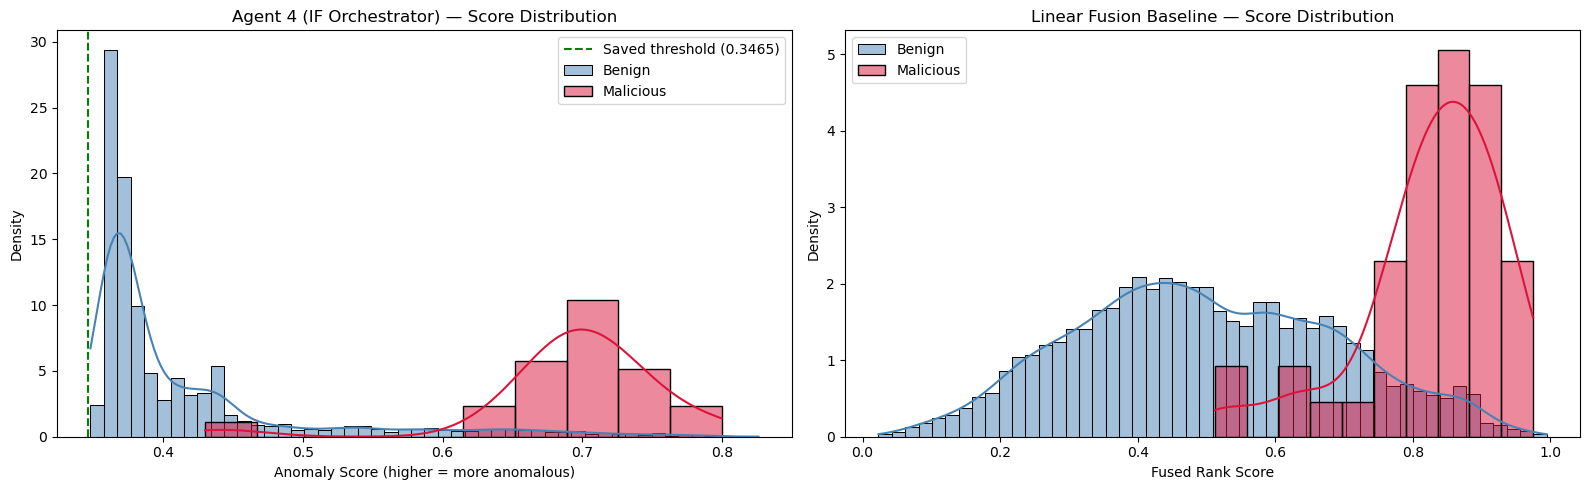

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax1 = axes[0]
sns.histplot(final_scores_if[y_test == 0], color='steelblue', label='Benign',
             kde=True, stat="density", bins=50, ax=ax1)
if y_test.sum() > 0:
    sns.histplot(final_scores_if[y_test == 1], color='crimson', label='Malicious',
                 kde=True, stat="density", bins=10, ax=ax1)
ax1.axvline(if_threshold, color='green', linestyle='--',
            label=f"Saved threshold ({if_threshold:.4f})")
ax1.set_title("Agent 4 (IF Orchestrator) — Score Distribution")
ax1.set_xlabel("Anomaly Score (higher = more anomalous)")
ax1.set_ylabel("Density")
ax1.legend()

ax2 = axes[1]
sns.histplot(final_scores_linear[y_test == 0], color='steelblue', label='Benign',
             kde=True, stat="density", bins=50, ax=ax2)
if y_test.sum() > 0:
    sns.histplot(final_scores_linear[y_test == 1], color='crimson', label='Malicious',
                 kde=True, stat="density", bins=10, ax=ax2)
ax2.set_title("Linear Fusion Baseline — Score Distribution")
ax2.set_xlabel("Fused Rank Score")
ax2.set_ylabel("Density")
ax2.legend()

plt.tight_layout()
plt.show()

### Confusion Matrix

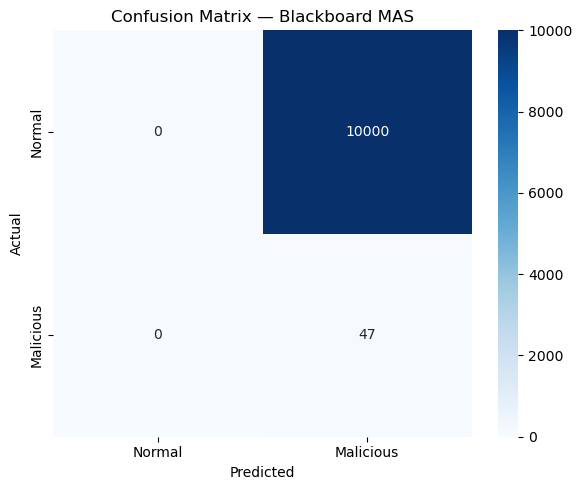

In [17]:
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Malicious'],
            yticklabels=['Normal', 'Malicious'])
plt.title("Confusion Matrix — Blackboard MAS")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### ROC Curve — All Agents

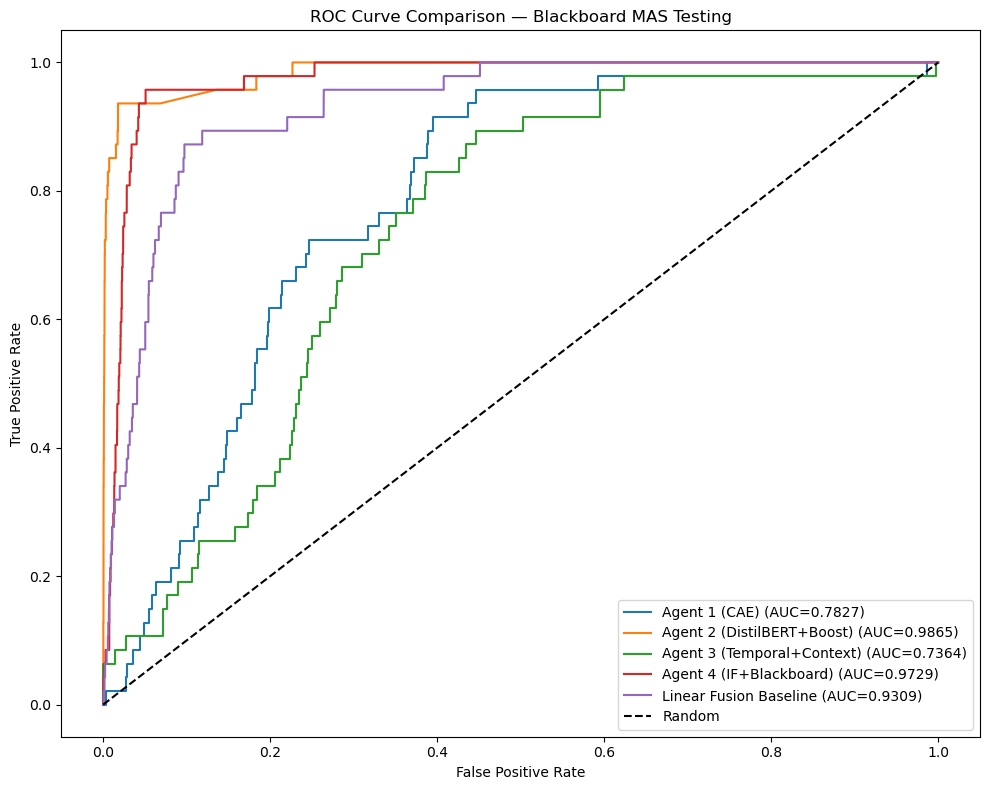

In [18]:
if len(np.unique(y_test)) > 1:
    fig, ax = plt.subplots(figsize=(10, 8))
    for name, scores, auc_val in [
        ("Agent 1 (CAE)",             reconstruction_errors, agent1_auc),
        ("Agent 2 (DistilBERT+Boost)", semantic_scores,       agent2_auc),
        ("Agent 3 (Temporal+Context)", temporal_scores,       agent3_auc),
        ("Agent 4 (IF+Blackboard)",   final_scores_if,        if_auc),
        ("Linear Fusion Baseline",    final_scores_linear,    linear_auc),
    ]:
        fpr, tpr, _ = roc_curve(y_test, scores)
        ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")
    ax.plot([0,1],[0,1],'k--',label='Random')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve Comparison — Blackboard MAS Testing")
    ax.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    print("ROC curve requires both classes in y_test.")